In [32]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

cols = ["X2","X3","X1"] # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

data[cols] = (data[cols] - data[cols].mean()) / data[cols].std()

whole = data.copy()

data = data.iloc[0:8,:]

validation = whole.iloc[70:100,:]

print(len(whole))
print(len(data))
print(len(validation))
print(data)

100
8
30
         X2        X3        X1         Y    raw_x1    raw_x2    raw_x3
0  2.985660 -0.455945  0.902386  4.686122  0.650593  2.913862 -0.529439
1  2.183840  0.287470  0.274274  4.410815  0.162753  2.128470  0.232170
2  1.646134 -0.089969  1.195760  3.444338  0.878450  1.601779 -0.154506
3  1.815760  0.819613 -0.757854  3.378867 -0.638878  1.767930  0.777338
4  2.049346 -0.976188 -0.996825  3.135581 -0.824481  1.996731 -1.062414
5  0.863432  0.149174 -0.486764  3.060039 -0.428328  0.835111  0.090490
6  0.187052  0.437475  0.953749  3.033309  0.690485  0.172588  0.385847
7  1.504762  2.518179  0.750091  2.743355  0.532309  1.463303  2.517474


In [ ]:
import torch

X = torch.tensor(
    data[cols].values,
    dtype=torch.float32
)

y = torch.tensor(
    data["Y"].values,
    dtype=torch.float32
)

# y_true = y.mean()

# y_true = y_true.reshape(1,1)

N = X.shape[0]
P = X.shape[1]

In [23]:
y

tensor([4.6861, 4.4108, 3.4443, 3.3789, 3.1356, 3.0600, 3.0333, 2.7434])

In [25]:
X

tensor([[ 2.9857, -0.4559,  0.9024],
        [ 2.1838,  0.2875,  0.2743],
        [ 1.6461, -0.0900,  1.1958],
        [ 1.8158,  0.8196, -0.7579],
        [ 2.0493, -0.9762, -0.9968],
        [ 0.8634,  0.1492, -0.4868],
        [ 0.1871,  0.4375,  0.9537],
        [ 1.5048,  2.5182,  0.7501]])

In [34]:
import torch.nn as nn

embedding_dim = len(data)
dk = 4

wq = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

wk = torch.randn(
    dk,
    embedding_dim,
    requires_grad=True
)

# 先不需要V
# wv = torch.randn(
#     embedding_dim,
#     embedding_dim,
#     requires_grad=True
# )

# proj = nn.Linear(
#     embedding_dim,
#     1
# )

# linear = nn.Linear(
#     P,
#     1
# )

In [35]:
optimizer = torch.optim.Adam(

    [wq,wk], # wv

    # +list(proj.parameters())

    # +list(linear.parameters()),

    lr=0.001

)

In [ ]:
import numpy as np
import torch.nn.functional as F

lam = 1

p = X.shape[1]

I = torch.eye(
    p,
    dtype=X.dtype,
    device=X.device
)

loss_history = []

initial_attn = None

epochs = 1000

for epoch in range(epochs):

    E = X

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q 

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=0
    )

    A = attn @ attn.T + lam * I

    # beta
    beta = torch.linalg.solve(
    X.T @ X + A,
    X.T @ y
    )

    # V = wv @ E

    # delta_E = V @ attn

    # New_E = E + delta_E

    # z = proj(
    # New_E.T
    # )

    # z = z.reshape(1,-1)

    # y_hat = linear(z)

#    mse_loss = F.mse_loss(
#    y_hat,
#    y
#    )

#    lambda_attn=0.1

#    loss = (
#        mse_loss
#        +
#        lambda_attn *
#        torch.mean(attn**2)
#    )

    y_hat = X @ beta

    loss = F.mse_loss(
    y_hat,
    y
    )


    if epoch == 0:
        initial_attn = attn.detach().clone()

        mean_initial_attn = initial_attn.mean(dim=0)

        print(E.shape)

        print(Q.shape)

        print(K.shape)

        print(scores.shape)

        print(attn.shape)

        # print(V.shape)

        # print(delta_E.shape)

        # print(New_E.shape)

        # print(z.shape)

        print(y_hat.shape)
        
        print(y.shape)


    loss_history.append(
        loss.item()
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

# =====================
# 訓練完成後重新 forward
# 取得最後 attention
# =====================

with torch.no_grad():

    E = X

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q 

    scores = scores / np.sqrt(dk)

    attn = F.softmax(
        scores,
        dim=0
    )

    final_attn = attn.clone()

# =====================
# Average attention matrix across all samples
# =====================

# mean_attn = final_attn.mean(dim=0)



C:\Users\USER\AppData\Local\Temp\ipykernel_31888\480294717.py:75: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(


torch.Size([8, 3])
torch.Size([4, 3])
torch.Size([4, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([8])
torch.Size([8])


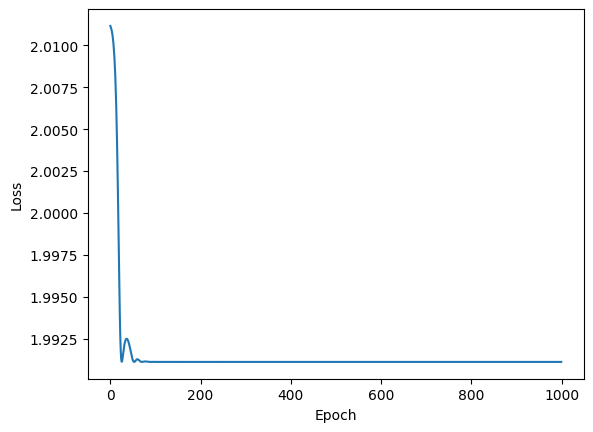

In [37]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

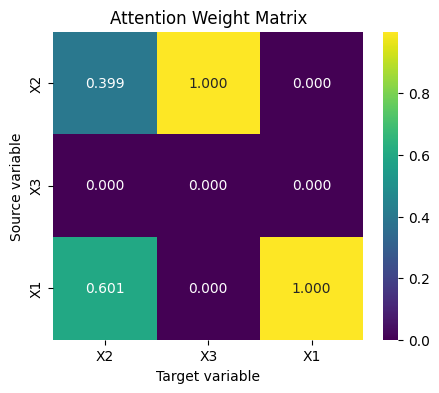

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
# 轉成 numpy
attn_matrix = final_attn.detach().numpy()

# 設定變數名稱
labels = cols

plt.figure(figsize=(5,4))

sns.heatmap(
    attn_matrix,
    annot=True,        # 顯示數值
    fmt=".3f",         # 小數三位
    xticklabels=labels,
    yticklabels=labels,
    cmap="viridis"
)

plt.xlabel("Target variable")
plt.ylabel("Source variable")
plt.title("Attention Weight Matrix")

plt.show()

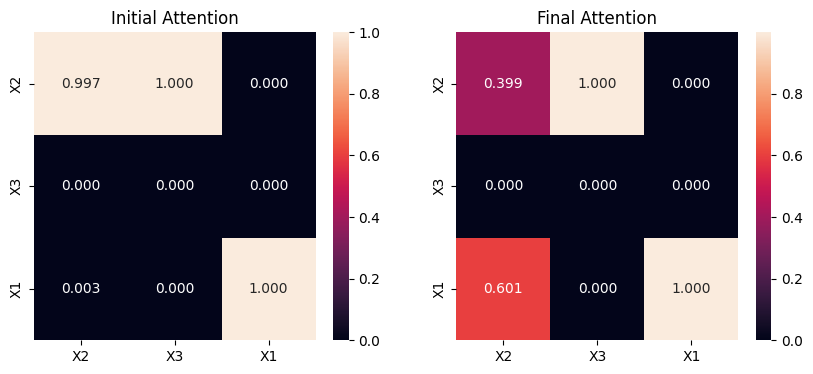

In [39]:
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.heatmap(
    initial_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Initial Attention")


sns.heatmap(
    final_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Final Attention")


plt.show()